# 09 — Long random-sequence odor shape maps

This notebook applies the **unchanged frozen** mint/lavender identity and
active/fading temporal models to the five reviewed July 30 moving sequences.
It uses host-derived physical time, a fixed 2.0 s pose correction, the existing
1.0–3.5 cm height rule, and the existing 3 cm spatial kernel.

The source layouts were described in the recorder metadata, but exact strip
vertices were not saved numerically. The overlays below are therefore
**protocol-approximate geometry**, declared before looking at model scores.
They help us ask whether the recovered field resembles the intended horizontal,
caret, or inverted-caret layout; they are not millimeter-accurate ground truth.
The constants are collected in one cell so measured coordinates can replace
them later without changing the models or analysis rules.

The main questions are:

1. Do the pure mint and pure lavender runs concentrate their corresponding
   active evidence near the same centered horizontal strip?
2. In the mixed layouts, does each odor channel rank its intended diagonal
   above the surrounding paper and the other odor's diagonal?
3. Is the apparent geometry stable across nearby fixed lag corrections?
4. Where do the frozen models report fading or simultaneous/ambiguous evidence?


In [1]:
import sys
import site
from pathlib import Path
import hashlib
import json

USER_SITE = Path(site.getusersitepackages()).resolve()
sys.path[:] = [
    entry for entry in sys.path
    if not entry or Path(entry).resolve() != USER_SITE
]

import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch, Polygon
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "record_cyranose_reading_pose.py").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Run this notebook from inside the realsense-apriltag repository."
    )


ROOT = find_repo_root()
REPORT_DIR = ROOT / "analysis" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PAPER_SIZE_CM = 26.5
PAPER_LEFT_DESK_X_CM = 40.0
PAPER_TOP_DESK_Y_CM = 46.5
WORKING_LAG_S = 2.0
LAG_SENSITIVITY_S = (1.5, 2.0, 2.25)
MAX_INTERPOLATION_GAP_S = 1.5
STRICT_HEIGHT_BAND_CM = (1.0, 3.5)
ODOR_PRESENCE_THRESHOLD = 0.5
GRID_STEP_CM = 0.5
GRID_X = np.arange(0.0, PAPER_SIZE_CM + 0.001, GRID_STEP_CM)
GRID_Y = np.arange(0.0, PAPER_SIZE_CM + 0.001, GRID_STEP_CM)
SMOOTH_RADIUS_CM = 3.0
SMOOTH_SIGMA_CM = 1.7
MIN_NEIGHBORS = 2

NAVY = "#0b1f47"
MINT = "#9ee6c4"
LAVENDER = "#c8b5ff"
MINT_FADE = "#69bd88"
LAVENDER_FADE = "#9276cf"
AMBIGUOUS = "#ef4444"
UNSUPPORTED = "#eef1f5"
TRACK = "#c7ccd6"

IDENTITY_VERSION = "mint-lavender-ambient-v1"
MINT_TEMPORAL_VERSION = "temporal-mint-seeker-v1"
LAVENDER_TEMPORAL_VERSION = "temporal-lavender-seeker-v1"
EXPECTED_IDENTITY_SHA256 = (
    "73d292015272a6fe69ee0bd2ce35f8fd85769068eb6b213b9acaa5ebb5e08b83"
)
EXPECTED_MINT_TEMPORAL_SHA256 = (
    "7a3c3a6e078073f9e0c7e92ba7c3ec91ac0a04f64a12e6bb2f646f60cc4cb2b2"
)
EXPECTED_LAVENDER_TEMPORAL_SHA256 = (
    "c11d837492b30c2d0c824826c3819749756a73a9698c1992f54ef9d7ff65228a"
)

# Protocol-approximate 17 x 3 cm strips. These are visualization and
# exploratory-scoring assumptions, not coordinates measured from a setup photo.
SEGMENTS = {
    "horizontal": {
        "start": (4.75, 13.25),
        "end": (21.75, 13.25),
        "width": 3.0,
    },
    "caret_left": {
        "start": (4.75, 21.5),
        "end": (11.25, 5.0),
        "width": 3.0,
    },
    "caret_right": {
        "start": (15.25, 5.0),
        "end": (21.75, 21.5),
        "width": 3.0,
    },
    "inverted_left": {
        "start": (4.75, 5.0),
        "end": (11.25, 21.5),
        "width": 3.0,
    },
    "inverted_right": {
        "start": (15.25, 21.5),
        "end": (21.75, 5.0),
        "width": 3.0,
    },
}

RUN_SPECS = [
    {
        "key": "mint_horizontal",
        "title": "Mint only — horizontal",
        "session_id": "cyranose_reading_pose_session_20260730_152754",
        "sources": {"mint": ["horizontal"], "lavender": []},
    },
    {
        "key": "lavender_horizontal",
        "title": "Lavender only — horizontal",
        "session_id": "cyranose_reading_pose_session_20260730_161358",
        "sources": {"mint": [], "lavender": ["horizontal"]},
    },
    {
        "key": "caret_mint_left",
        "title": "Caret ^ — mint left, lavender right",
        "session_id": "cyranose_reading_pose_session_20260730_153631",
        "sources": {
            "mint": ["caret_left"],
            "lavender": ["caret_right"],
        },
    },
    {
        "key": "caret_lavender_left",
        "title": "Caret ^ — lavender left, mint right",
        "session_id": "cyranose_reading_pose_session_20260730_154848",
        "sources": {
            "mint": ["caret_right"],
            "lavender": ["caret_left"],
        },
    },
    {
        "key": "inverted_caret_lavender_left",
        "title": "Inverted caret V — lavender left, mint right",
        "session_id": "cyranose_reading_pose_session_20260730_163355",
        "sources": {
            "mint": ["inverted_right"],
            "lavender": ["inverted_left"],
        },
    },
]

print("Repository:", ROOT)
print(
    "Physical time basis: pcnose_sample_time_estimate_utc "
    "(host serial-request midpoint)"
)
print(
    "Paper registration: paper_x = 40 - desk_x; "
    "paper_y = 46.5 - desk_y"
)


Repository: c:\Users\dell-xps\Documents\realsense-apriltag
Physical time basis: pcnose_sample_time_estimate_utc (host serial-request midpoint)
Paper registration: paper_x = 40 - desk_x; paper_y = 46.5 - desk_y


In [2]:
def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def find_session_by_id(session_id):
    matches = [
        path
        for path in ROOT.rglob(session_id)
        if path.is_dir() and (path / "session_metadata.json").exists()
    ]
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one complete session {session_id!r}; found {matches}"
        )
    return matches[0]


identity_dir = (
    ROOT
    / "experiments"
    / "classifier"
    / "mint-lavender-ambient-pilot-01"
    / "frozen-models"
    / IDENTITY_VERSION
)
mint_temporal_dir = (
    ROOT
    / "experiments"
    / "classifier"
    / "mint-identity-pilot-01"
    / "frozen-models"
    / MINT_TEMPORAL_VERSION
)
lavender_temporal_dir = (
    ROOT
    / "experiments"
    / "classifier"
    / "mint-lavender-ambient-pilot-01"
    / "frozen-models"
    / LAVENDER_TEMPORAL_VERSION
)

identity_path = identity_dir / "model.joblib"
mint_temporal_path = mint_temporal_dir / "model.joblib"
lavender_temporal_path = lavender_temporal_dir / "model.joblib"

assert sha256(identity_path) == EXPECTED_IDENTITY_SHA256
assert sha256(mint_temporal_path) == EXPECTED_MINT_TEMPORAL_SHA256
assert (
    sha256(lavender_temporal_path)
    == EXPECTED_LAVENDER_TEMPORAL_SHA256
)

identity_bundle = joblib.load(identity_path)
mint_temporal_bundle = joblib.load(mint_temporal_path)
lavender_temporal_bundle = joblib.load(lavender_temporal_path)

assert identity_bundle["bundle_name"] == IDENTITY_VERSION
assert mint_temporal_bundle["artifact_version"] == MINT_TEMPORAL_VERSION
assert (
    lavender_temporal_bundle["artifact_version"]
    == LAVENDER_TEMPORAL_VERSION
)

for spec in RUN_SPECS:
    spec["session"] = find_session_by_id(spec["session_id"])
    spec["metadata"] = json.loads(
        (spec["session"] / "session_metadata.json").read_text(
            encoding="utf-8"
        )
    )
    spec["alignment"] = json.loads(
        (spec["session"] / "alignment_summary.json").read_text(
            encoding="utf-8"
        )
    )

display(
    pd.DataFrame(
        [
            {
                "run": spec["title"],
                "session": spec["session_id"].removeprefix(
                    "cyranose_reading_pose_session_"
                ),
                "trial ID": spec["metadata"]["trial_id"],
            }
            for spec in RUN_SPECS
        ]
    )
)

display(
    Markdown(
        f'''**Frozen-artifact verification passed.**

- Identity SHA-256: `{EXPECTED_IDENTITY_SHA256}`
- Mint temporal SHA-256: `{EXPECTED_MINT_TEMPORAL_SHA256}`
- Lavender temporal SHA-256: `{EXPECTED_LAVENDER_TEMPORAL_SHA256}`
- No model is retrained, selected, or tuned in this notebook.
'''
    )
)


,run,session,trial ID
0,Mint only — horizontal,20260730_152754,2026-07-30_mint_only_horizontal_random_10min_r...
1,Lavender only — horizontal,20260730_161358,2026-07-30_lavender_only_horizontal_random_10m...
2,"Caret ^ — mint left, lavender right",20260730_153631,2026-07-30_caret_mint_left_lavender_right_rand...
3,"Caret ^ — lavender left, mint right",20260730_154848,2026-07-30_caret_lavender_left_mint_right_rand...
4,"Inverted caret V — lavender left, mint right",20260730_163355,2026-07-30_inverted_caret_lavender_left_mint_r...


**Frozen-artifact verification passed.**

- Identity SHA-256: `73d292015272a6fe69ee0bd2ce35f8fd85769068eb6b213b9acaa5ebb5e08b83`
- Mint temporal SHA-256: `7a3c3a6e078073f9e0c7e92ba7c3ec91ac0a04f64a12e6bb2f646f60cc4cb2b2`
- Lavender temporal SHA-256: `c11d837492b30c2d0c824826c3819749756a73a9698c1992f54ef9d7ff65228a`
- No model is retrained, selected, or tuned in this notebook.


In [3]:
SENSOR_COLUMNS = [f"pcnose_S{i}_kohm" for i in range(1, 33)]
SCORE_COLUMNS = [
    "rms_pct",
    "odor_score",
    "mint_given_odor",
    "lavender_given_odor",
    "mint_score",
    "lavender_score",
    "active_mint",
    "fading_mint",
    "active_lavender",
    "fading_lavender",
]


def l2_normalize(matrix):
    matrix = np.asarray(matrix, dtype=float)
    return matrix / np.maximum(
        np.linalg.norm(matrix, axis=1, keepdims=True), 1e-12
    )


def irregular_ema(times, values, tau_s):
    result = np.empty_like(values, dtype=float)
    result[0] = values[0]
    for index in range(1, len(values)):
        dt = max(float(times[index] - times[index - 1]), 0.0)
        alpha = np.exp(-dt / tau_s)
        result[index] = (
            alpha * result[index - 1]
            + (1.0 - alpha) * values[index]
        )
    return result


def interpolate_vectors(times, values, query_times):
    return np.column_stack(
        [
            np.interp(query_times, times, values[:, sensor_index])
            for sensor_index in range(values.shape[1])
        ]
    )


def build_temporal_features(times, values, indices, config):
    current = values[indices]
    parts = [current]
    for lookback_s in config["lookbacks"]:
        previous = interpolate_vectors(
            times, values, times[indices] - lookback_s
        )
        parts.append(current - previous)
    for tau_s in config["ema_taus"]:
        ema = irregular_ema(times, values, tau_s)
        parts.append(current - ema[indices])
    return np.column_stack(parts)


def aligned_state_proba(model, features, state_order):
    raw = model.predict_proba(features)
    result = np.zeros((len(features), len(state_order)), dtype=float)
    for source_column, state in enumerate(model.classes_):
        result[:, state_order.index(state)] = raw[:, source_column]
    return result


def read_and_score(spec):
    frame = pd.read_csv(spec["session"] / "cyranose_reading_pose.csv")
    host_time = pd.to_datetime(
        frame["pcnose_sample_time_estimate_utc"],
        errors="coerce",
        utc=True,
    )
    assert host_time.notna().all()
    host_elapsed = (
        host_time - host_time.iloc[0]
    ).dt.total_seconds().to_numpy(float)
    frame["host_elapsed_s"] = host_elapsed

    flags = (
        pd.to_numeric(frame["pcnose_flag"], errors="coerce")
        .fillna(-1)
        .astype(int)
        .to_numpy()
    )
    resistance = (
        frame[SENSOR_COLUMNS]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(float)
    )
    assert np.isfinite(resistance).all()
    flag1 = resistance[flags == 1]
    assert len(flag1) >= 4
    baseline = np.median(flag1[len(flag1) // 2 :], axis=0)
    response = 100.0 * (resistance - baseline) / baseline
    smoothed_response = (
        pd.DataFrame(response)
        .rolling(3, min_periods=1)
        .median()
        .to_numpy(float)
    )

    minimum_history_s = max(
        float(mint_temporal_bundle["minimum_history_s"]),
        float(lavender_temporal_bundle["minimum_history_s"]),
    )
    indices = np.flatnonzero(
        (flags == 2) & (host_elapsed >= minimum_history_s)
    )
    identity_x = smoothed_response[indices]
    odor_score = identity_bundle["presence_model"].predict_proba(
        identity_x
    )[:, 1]
    mint_given_odor = identity_bundle["identity_model"].predict_proba(
        l2_normalize(identity_x)
    )[:, 1]
    lavender_given_odor = 1.0 - mint_given_odor

    mint_features = build_temporal_features(
        host_elapsed,
        response,
        indices,
        mint_temporal_bundle["feature_config"],
    )
    mint_order = list(mint_temporal_bundle["state_order"])
    mint_states = aligned_state_proba(
        mint_temporal_bundle["temporal_model"],
        mint_features,
        mint_order,
    )
    active_mint_raw = mint_states[:, mint_order.index("active_mint")]
    fading_mint = mint_states[:, mint_order.index("mint_recovery")]

    lavender_features = build_temporal_features(
        host_elapsed,
        response,
        indices,
        lavender_temporal_bundle["feature_config"],
    )
    lavender_order = list(lavender_temporal_bundle["state_order"])
    lavender_states = aligned_state_proba(
        lavender_temporal_bundle["temporal_model"],
        lavender_features,
        lavender_order,
    )
    active_lavender_raw = lavender_states[
        :, lavender_order.index("active_lavender")
    ]
    fading_lavender = lavender_states[
        :, lavender_order.index("lavender_recovery")
    ]

    scored = frame.iloc[indices].copy()
    scored["host_elapsed_s"] = host_elapsed[indices]
    scored["rms_pct"] = np.sqrt(
        np.mean(response[indices] ** 2, axis=1)
    )
    scored["odor_score"] = odor_score
    scored["mint_given_odor"] = mint_given_odor
    scored["lavender_given_odor"] = lavender_given_odor
    scored["mint_score"] = odor_score * mint_given_odor
    scored["lavender_score"] = odor_score * lavender_given_odor
    scored["active_mint"] = (
        np.where(
            odor_score >= ODOR_PRESENCE_THRESHOLD,
            active_mint_raw,
            0.0,
        )
        * mint_given_odor
    )
    scored["fading_mint"] = fading_mint
    scored["active_lavender"] = (
        np.where(
            odor_score >= ODOR_PRESENCE_THRESHOLD,
            active_lavender_raw,
            0.0,
        )
        * lavender_given_odor
    )
    scored["fading_lavender"] = fading_lavender
    return {
        "frame": frame,
        "flags": flags,
        "response": response,
        "scored": scored,
        "duration_s": float(host_elapsed[-1] - host_elapsed[0]),
        "minimum_history_s": minimum_history_s,
    }


RUNS = {}
for spec in RUN_SPECS:
    result = read_and_score(spec)
    result["spec"] = spec
    RUNS[spec["key"]] = result

print("Scored all reviewed sessions with host-derived physical time.")


Scored all reviewed sessions with host-derived physical time.


In [4]:
def point_segment_distance(x, y, segment):
    start = np.asarray(segment["start"], dtype=float)
    end = np.asarray(segment["end"], dtype=float)
    points = np.column_stack(
        [np.asarray(x, dtype=float), np.asarray(y, dtype=float)]
    )
    direction = end - start
    denominator = float(direction @ direction)
    fraction = np.clip(
        ((points - start) @ direction) / denominator, 0.0, 1.0
    )
    closest = start + fraction[:, None] * direction
    return np.linalg.norm(points - closest, axis=1)


def source_mask(x, y, segment_names):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if not segment_names:
        return np.zeros(len(x), dtype=bool)
    distances = np.column_stack(
        [
            point_segment_distance(x, y, SEGMENTS[name])
            for name in segment_names
        ]
    )
    half_widths = np.asarray(
        [SEGMENTS[name]["width"] / 2.0 for name in segment_names]
    )
    return np.any(distances <= half_widths, axis=1)


def align_scores_to_paper(run, lag_s):
    frame = run["frame"].copy()
    scored = run["scored"].copy()
    pose_columns = [
        "pose_elapsed_s",
        "snout_desk_x_cm",
        "snout_desk_y_cm",
        "snout_desk_z_cm",
    ]
    pose = frame[pose_columns].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()
    pose = (
        pose.sort_values("pose_elapsed_s")
        .drop_duplicates("pose_elapsed_s")
        .reset_index(drop=True)
    )
    pose_times = pose["pose_elapsed_s"].to_numpy(float)
    pose_xyz = pose[
        ["snout_desk_x_cm", "snout_desk_y_cm", "snout_desk_z_cm"]
    ].to_numpy(float)

    reading_pose_times = pd.to_numeric(
        scored["pose_elapsed_s"], errors="coerce"
    ).to_numpy(float)
    records = []
    for row_position, (_, reading) in enumerate(scored.iterrows()):
        reading_pose_time = reading_pose_times[row_position]
        if not np.isfinite(reading_pose_time):
            continue
        corrected_time = float(reading_pose_time) - float(lag_s)
        index = int(np.searchsorted(pose_times, corrected_time))
        if index == 0 or index == len(pose_times):
            continue
        gap = float(pose_times[index] - pose_times[index - 1])
        if gap <= 0 or gap > MAX_INTERPOLATION_GAP_S:
            continue
        fraction = (
            corrected_time - pose_times[index - 1]
        ) / gap
        desk_x, desk_y, desk_z = (
            pose_xyz[index - 1]
            + fraction * (pose_xyz[index] - pose_xyz[index - 1])
        )
        paper_x = PAPER_LEFT_DESK_X_CM - desk_x
        paper_y = PAPER_TOP_DESK_Y_CM - desk_y
        if not (
            0.0 <= paper_x <= PAPER_SIZE_CM
            and 0.0 <= paper_y <= PAPER_SIZE_CM
        ):
            continue
        record = {
            "host_elapsed_s": float(reading["host_elapsed_s"]),
            "paper_x": float(paper_x),
            "paper_y": float(paper_y),
            "height": abs(float(desk_z)),
            "lag_s": float(lag_s),
        }
        for column in SCORE_COLUMNS:
            record[column] = float(reading[column])
        records.append(record)

    aligned = pd.DataFrame(records)
    spec = run["spec"]
    aligned["mint_source"] = source_mask(
        aligned["paper_x"],
        aligned["paper_y"],
        spec["sources"]["mint"],
    )
    aligned["lavender_source"] = source_mask(
        aligned["paper_x"],
        aligned["paper_y"],
        spec["sources"]["lavender"],
    )
    aligned["strict_height"] = aligned["height"].between(
        *STRICT_HEIGHT_BAND_CM
    )
    return aligned


for run in RUNS.values():
    run["aligned"] = align_scores_to_paper(run, WORKING_LAG_S)


qc_rows = []
for run in RUNS.values():
    spec = run["spec"]
    frame = run["frame"]
    aligned = run["aligned"]
    sensor_finite = (
        frame[SENSOR_COLUMNS]
        .apply(pd.to_numeric, errors="coerce")
        .notna()
        .all(axis=1)
        .mean()
    )
    qc_rows.append(
        {
            "run": spec["title"],
            "host duration (min)": run["duration_s"] / 60.0,
            "readings": len(frame),
            "flag-2 rows": int((run["flags"] == 2).sum()),
            "sync match": (
                spec["alignment"]["matched_readings"]
                / spec["alignment"]["total_readings"]
            ),
            "p95 sync (ms)": spec["alignment"][
                "absolute_pose_minus_pcnose_ms"
            ]["p95"],
            "all 32 sensors finite": sensor_finite,
            "paper-local causal rows": len(aligned),
            "strict-height rows": int(
                aligned["strict_height"].sum()
            ),
            "median height (cm)": aligned["height"].median(),
        }
    )

qc_table = pd.DataFrame(qc_rows)
display(
    qc_table.style.format(
        {
            "host duration (min)": "{:.2f}",
            "sync match": "{:.1%}",
            "p95 sync (ms)": "{:.1f}",
            "all 32 sensors finite": "{:.1%}",
            "median height (cm)": "{:.2f}",
        }
    )
)

display(
    Markdown(
        '''**QC rule.** Heatmaps use only flag-2 readings with sufficient
causal history, a valid 2.0 s lag-corrected paper pose, and snout height inside
1.0–3.5 cm. Missing/invalid pose rows remain missing; spatial smoothing does
not invent a score for unsupported cells.'''
    )
)


,run,host duration (min),readings,flag-2 rows,sync match,p95 sync (ms),all 32 sensors finite,paper-local causal rows,strict-height rows,median height (cm)
0,Mint only — horizontal,6.54,706,648,100.0%,85.3,100.0%,577,564,2.05
1,Lavender only — horizontal,7.68,829,782,100.0%,88.8,100.0%,660,654,1.88
2,"Caret ^ — mint left, lavender right",6.83,737,715,100.0%,95.2,100.0%,653,581,2.00
3,"Caret ^ — lavender left, mint right",7.03,759,705,100.0%,92.9,100.0%,609,556,1.73
4,"Inverted caret V — lavender left, mint right",10.32,1114,1088,100.0%,89.7,100.0%,970,915,1.86


**QC rule.** Heatmaps use only flag-2 readings with sufficient
causal history, a valid 2.0 s lag-corrected paper pose, and snout height inside
1.0–3.5 cm. Missing/invalid pose rows remain missing; spatial smoothing does
not invent a score for unsupported cells.

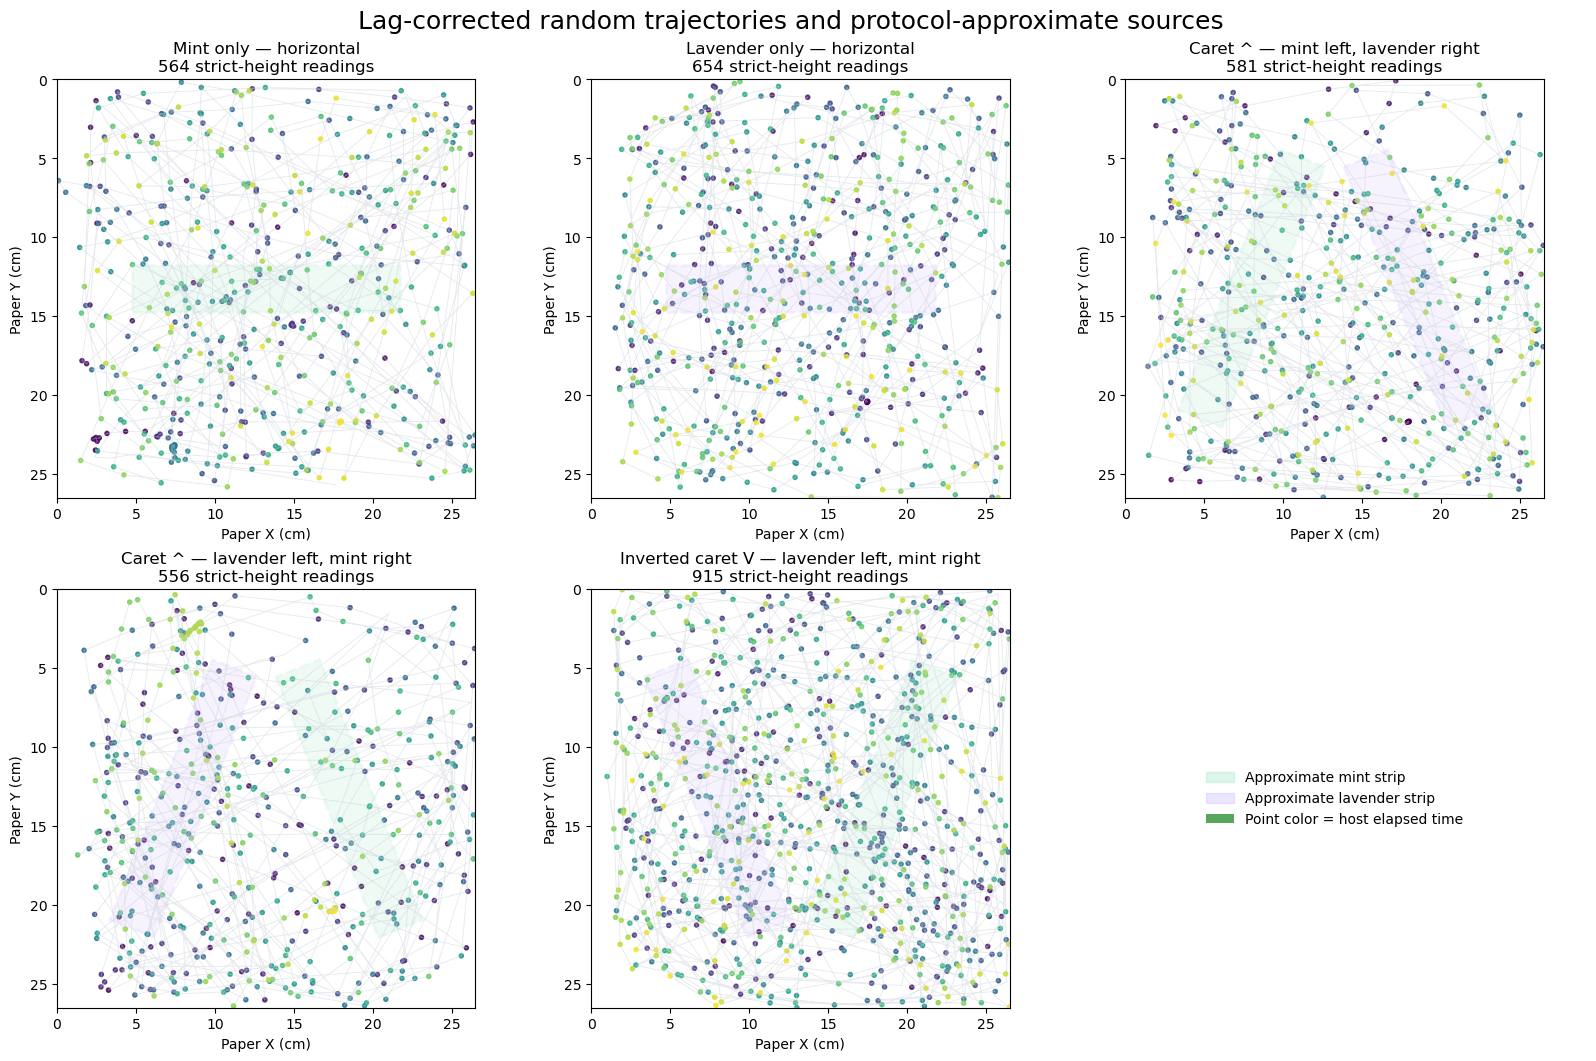

In [5]:
def segment_polygon(segment):
    start = np.asarray(segment["start"], dtype=float)
    end = np.asarray(segment["end"], dtype=float)
    direction = end - start
    normal = np.asarray([-direction[1], direction[0]], dtype=float)
    normal /= np.linalg.norm(normal)
    offset = normal * segment["width"] / 2.0
    return np.vstack(
        [start + offset, end + offset, end - offset, start - offset]
    )


def add_source_overlays(ax, spec, alpha=0.18):
    for odor, color in (("mint", MINT), ("lavender", LAVENDER)):
        for segment_name in spec["sources"][odor]:
            polygon = Polygon(
                segment_polygon(SEGMENTS[segment_name]),
                closed=True,
                facecolor=color,
                edgecolor=color,
                linewidth=2.0,
                linestyle="--",
                alpha=alpha,
            )
            ax.add_patch(polygon)


def format_paper_axis(ax, title=None):
    ax.set_xlim(0, PAPER_SIZE_CM)
    ax.set_ylim(PAPER_SIZE_CM, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Paper X (cm)")
    ax.set_ylabel("Paper Y (cm)")
    if title:
        ax.set_title(title)


fig, axes = plt.subplots(
    2, 3, figsize=(16, 10.5), constrained_layout=True
)
for ax, run in zip(axes.flat, RUNS.values()):
    local = run["aligned"]
    strict = local.loc[local["strict_height"]]
    ax.plot(
        local["paper_x"],
        local["paper_y"],
        color=TRACK,
        linewidth=0.65,
        alpha=0.42,
    )
    ax.scatter(
        strict["paper_x"],
        strict["paper_y"],
        c=strict["host_elapsed_s"],
        cmap="viridis",
        s=9,
        alpha=0.82,
    )
    add_source_overlays(ax, run["spec"], alpha=0.16)
    format_paper_axis(
        ax,
        f"{run['spec']['title']}\n"
        f"{len(strict)} strict-height readings",
    )

axes.flat[-1].axis("off")
axes.flat[-1].legend(
    handles=[
        Patch(
            facecolor=MINT,
            edgecolor=MINT,
            alpha=0.35,
            label="Approximate mint strip",
        ),
        Patch(
            facecolor=LAVENDER,
            edgecolor=LAVENDER,
            alpha=0.35,
            label="Approximate lavender strip",
        ),
        Patch(
            facecolor="#58a65c",
            label="Point color = host elapsed time",
        ),
    ],
    loc="center",
    frameon=False,
)
fig.suptitle(
    "Lag-corrected random trajectories and protocol-approximate sources",
    fontsize=18,
)
plt.show()


In [6]:
GRID_XX, GRID_YY = np.meshgrid(GRID_X, GRID_Y)
GRID_POINTS = np.column_stack([GRID_XX.ravel(), GRID_YY.ravel()])


def smooth_score_grids(aligned):
    strict = aligned.loc[aligned["strict_height"]].reset_index(drop=True)
    if len(strict) == 0:
        raise ValueError("No strict-height readings available")
    points = strict[["paper_x", "paper_y"]].to_numpy(float)
    delta = GRID_POINTS[:, None, :] - points[None, :, :]
    distance_sq = np.sum(delta**2, axis=2)
    neighbor = distance_sq <= SMOOTH_RADIUS_CM**2
    kernel = np.exp(
        -0.5 * distance_sq / (SMOOTH_SIGMA_CM**2)
    ) * neighbor
    denominator = kernel.sum(axis=1)
    neighbor_count = neighbor.sum(axis=1)
    supported = (
        (neighbor_count >= MIN_NEIGHBORS)
        & (denominator > 0)
    )

    grids = {}
    for column in SCORE_COLUMNS:
        values = strict[column].to_numpy(float)
        flattened = np.full(len(GRID_POINTS), np.nan)
        flattened[supported] = (
            kernel[supported] @ values
        ) / denominator[supported]
        grids[column] = flattened.reshape(GRID_XX.shape)

    grids["supported"] = supported.reshape(GRID_XX.shape)
    grids["neighbor_count"] = neighbor_count.reshape(GRID_XX.shape)
    return grids


for run in RUNS.values():
    run["grids"] = smooth_score_grids(run["aligned"])


def score_cmap(high_color):
    from matplotlib.colors import LinearSegmentedColormap

    return LinearSegmentedColormap.from_list(
        "odor_score", [NAVY, "#183665", high_color]
    )


MINT_CMAP = score_cmap(MINT)
LAVENDER_CMAP = score_cmap(LAVENDER)
MINT_FADE_CMAP = score_cmap(MINT_FADE)
LAVENDER_FADE_CMAP = score_cmap(LAVENDER_FADE)


def draw_heatmap(
    ax,
    run,
    column,
    cmap,
    title,
    vmin=0.0,
    vmax=1.0,
    show_track=True,
):
    grid = run["grids"][column]
    image = ax.imshow(
        grid,
        origin="upper",
        extent=[0, PAPER_SIZE_CM, PAPER_SIZE_CM, 0],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    if show_track:
        local = run["aligned"]
        ax.plot(
            local["paper_x"],
            local["paper_y"],
            color=TRACK,
            linewidth=0.55,
            alpha=0.26,
        )
    add_source_overlays(ax, run["spec"], alpha=0.15)
    format_paper_axis(ax, title)
    return image


def combined_rgb(
    run,
    mint_column="active_mint",
    lavender_column="active_lavender",
):
    mint_active = np.nan_to_num(
        run["grids"][mint_column], nan=0.0
    )
    lavender_active = np.nan_to_num(
        run["grids"][lavender_column], nan=0.0
    )
    support = (
        np.isfinite(run["grids"][mint_column])
        & np.isfinite(run["grids"][lavender_column])
    )
    shared = np.minimum(mint_active, lavender_active)
    mint_exclusive = np.clip(mint_active - shared, 0.0, 1.0)
    lavender_exclusive = np.clip(
        lavender_active - shared, 0.0, 1.0
    )
    strength = np.maximum(mint_active, lavender_active)

    base_rgb = np.asarray(to_rgb(NAVY))
    mint_rgb = np.asarray(to_rgb(MINT))
    lavender_rgb = np.asarray(to_rgb(LAVENDER))
    ambiguous_rgb = np.asarray(to_rgb(AMBIGUOUS))
    unsupported_rgb = np.asarray(to_rgb(UNSUPPORTED))

    rgb = (
        (1.0 - strength)[..., None] * base_rgb
        + mint_exclusive[..., None] * mint_rgb
        + lavender_exclusive[..., None] * lavender_rgb
        + shared[..., None] * ambiguous_rgb
    )
    rgb = np.clip(rgb, 0.0, 1.0)
    rgb[~support] = unsupported_rgb
    return rgb


print(
    "Fixed gridding:",
    f"{GRID_STEP_CM:g} cm cells,",
    f"{SMOOTH_RADIUS_CM:g} cm radius,",
    f"sigma {SMOOTH_SIGMA_CM:g} cm,",
    f"at least {MIN_NEIGHBORS} strict readings.",
)


Fixed gridding: 0.5 cm cells, 3 cm radius, sigma 1.7 cm, at least 2 strict readings.


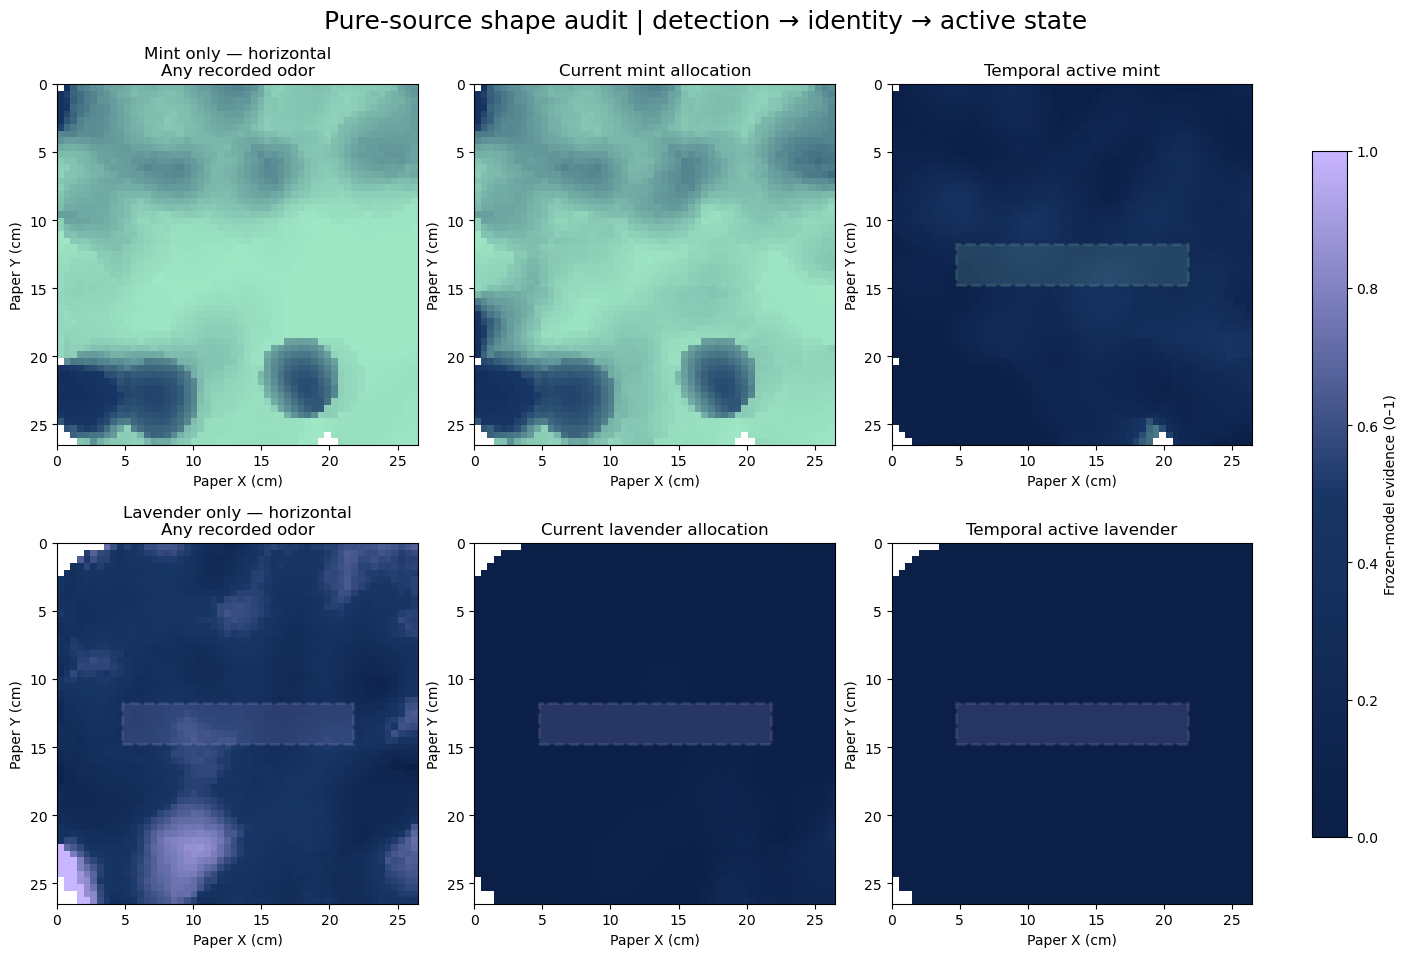

This separates three possible failure points. **Any recorded odor**
asks only whether the sensor response looks non-ambient. **Current allocation**
asks whether the frozen closed-panel identity model calls that response mint or
lavender. **Temporal active** additionally asks whether its recent history
looks like a new/continuing source rather than fading response. If the first
map contains structure but the later maps do not, localization and identity
transfer should not be treated as the same problem.

In [7]:
pure_runs = [
    RUNS["mint_horizontal"],
    RUNS["lavender_horizontal"],
]
fig, axes = plt.subplots(
    2, 3, figsize=(14, 9.5), constrained_layout=True
)
for row, run in enumerate(pure_runs):
    expected = "mint" if row == 0 else "lavender"
    expected_cmap = MINT_CMAP if expected == "mint" else LAVENDER_CMAP
    im = draw_heatmap(
        axes[row, 0],
        run,
        "odor_score",
        expected_cmap,
        f"{run['spec']['title']}\nAny recorded odor",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 1],
        run,
        f"{expected}_score",
        expected_cmap,
        f"Current {expected} allocation",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 2],
        run,
        f"active_{expected}",
        expected_cmap,
        f"Temporal active {expected}",
        show_track=False,
    )

fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.78,
    label="Frozen-model evidence (0–1)",
)
fig.suptitle(
    "Pure-source shape audit | detection → identity → active state",
    fontsize=18,
)
fig.savefig(
    REPORT_DIR / "09_long_random_sequence_pure_source_maps.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(
    Markdown(
        '''This separates three possible failure points. **Any recorded odor**
asks only whether the sensor response looks non-ambient. **Current allocation**
asks whether the frozen closed-panel identity model calls that response mint or
lavender. **Temporal active** additionally asks whether its recent history
looks like a new/continuing source rather than fading response. If the first
map contains structure but the later maps do not, localization and identity
transfer should not be treated as the same problem.'''
    )
)


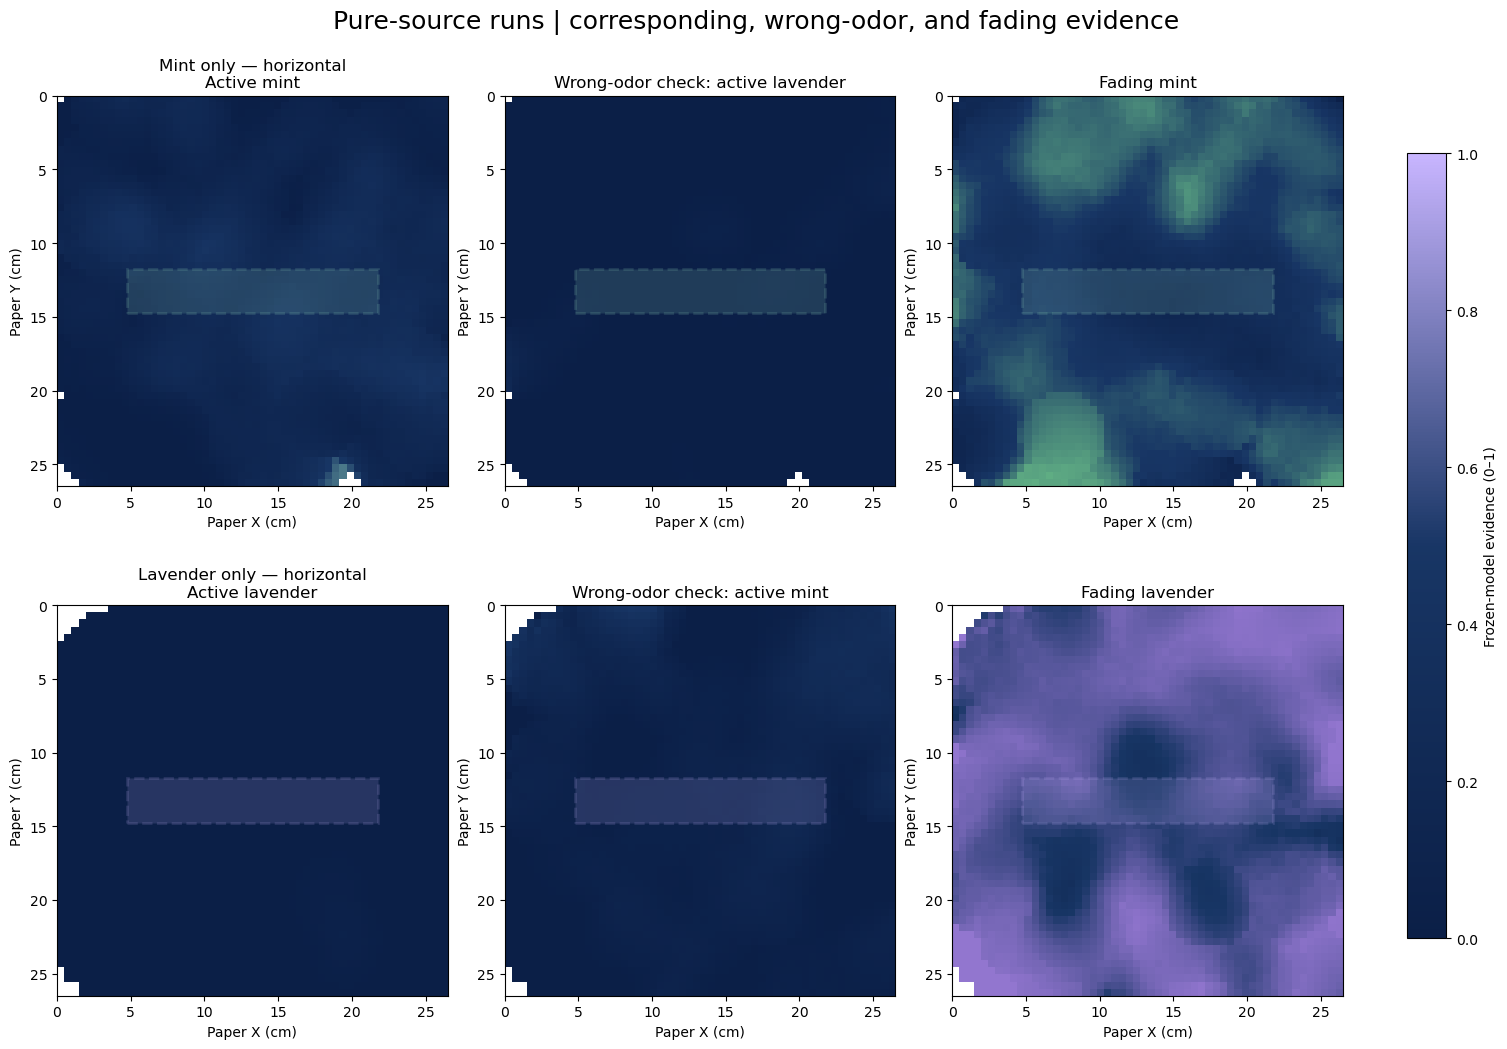

**How to read this figure.** The first column asks whether the
correct active-odor channel concentrates near the dashed horizontal strip.
The middle column is a specificity check: it should stay darker. The final
column shows the temporal model's fading state; it is not active odor and is
expected to extend away from a source after prior exposure. These values are
model evidence, not calibrated concentration.

In [8]:
pure_runs = [
    RUNS["mint_horizontal"],
    RUNS["lavender_horizontal"],
]
fig, axes = plt.subplots(
    2, 3, figsize=(15, 10.5), constrained_layout=True
)
for row, run in enumerate(pure_runs):
    expected = "mint" if row == 0 else "lavender"
    wrong = "lavender" if expected == "mint" else "mint"
    expected_color = MINT if expected == "mint" else LAVENDER
    wrong_color = LAVENDER if expected == "mint" else MINT
    fading_color = MINT_FADE if expected == "mint" else LAVENDER_FADE
    expected_cmap = MINT_CMAP if expected == "mint" else LAVENDER_CMAP
    wrong_cmap = LAVENDER_CMAP if expected == "mint" else MINT_CMAP
    fading_cmap = (
        MINT_FADE_CMAP if expected == "mint" else LAVENDER_FADE_CMAP
    )
    im = draw_heatmap(
        axes[row, 0],
        run,
        f"active_{expected}",
        expected_cmap,
        f"{run['spec']['title']}\nActive {expected}",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 1],
        run,
        f"active_{wrong}",
        wrong_cmap,
        f"Wrong-odor check: active {wrong}",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 2],
        run,
        f"fading_{expected}",
        fading_cmap,
        f"Fading {expected}",
        show_track=False,
    )

fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.78,
    label="Frozen-model evidence (0–1)",
)
fig.suptitle(
    "Pure-source runs | corresponding, wrong-odor, and fading evidence",
    fontsize=18,
)
plt.show()

display(
    Markdown(
        '''**How to read this figure.** The first column asks whether the
correct active-odor channel concentrates near the dashed horizontal strip.
The middle column is a specificity check: it should stay darker. The final
column shows the temporal model's fading state; it is not active odor and is
expected to extend away from a source after prior exposure. These values are
model evidence, not calibrated concentration.'''
    )
)


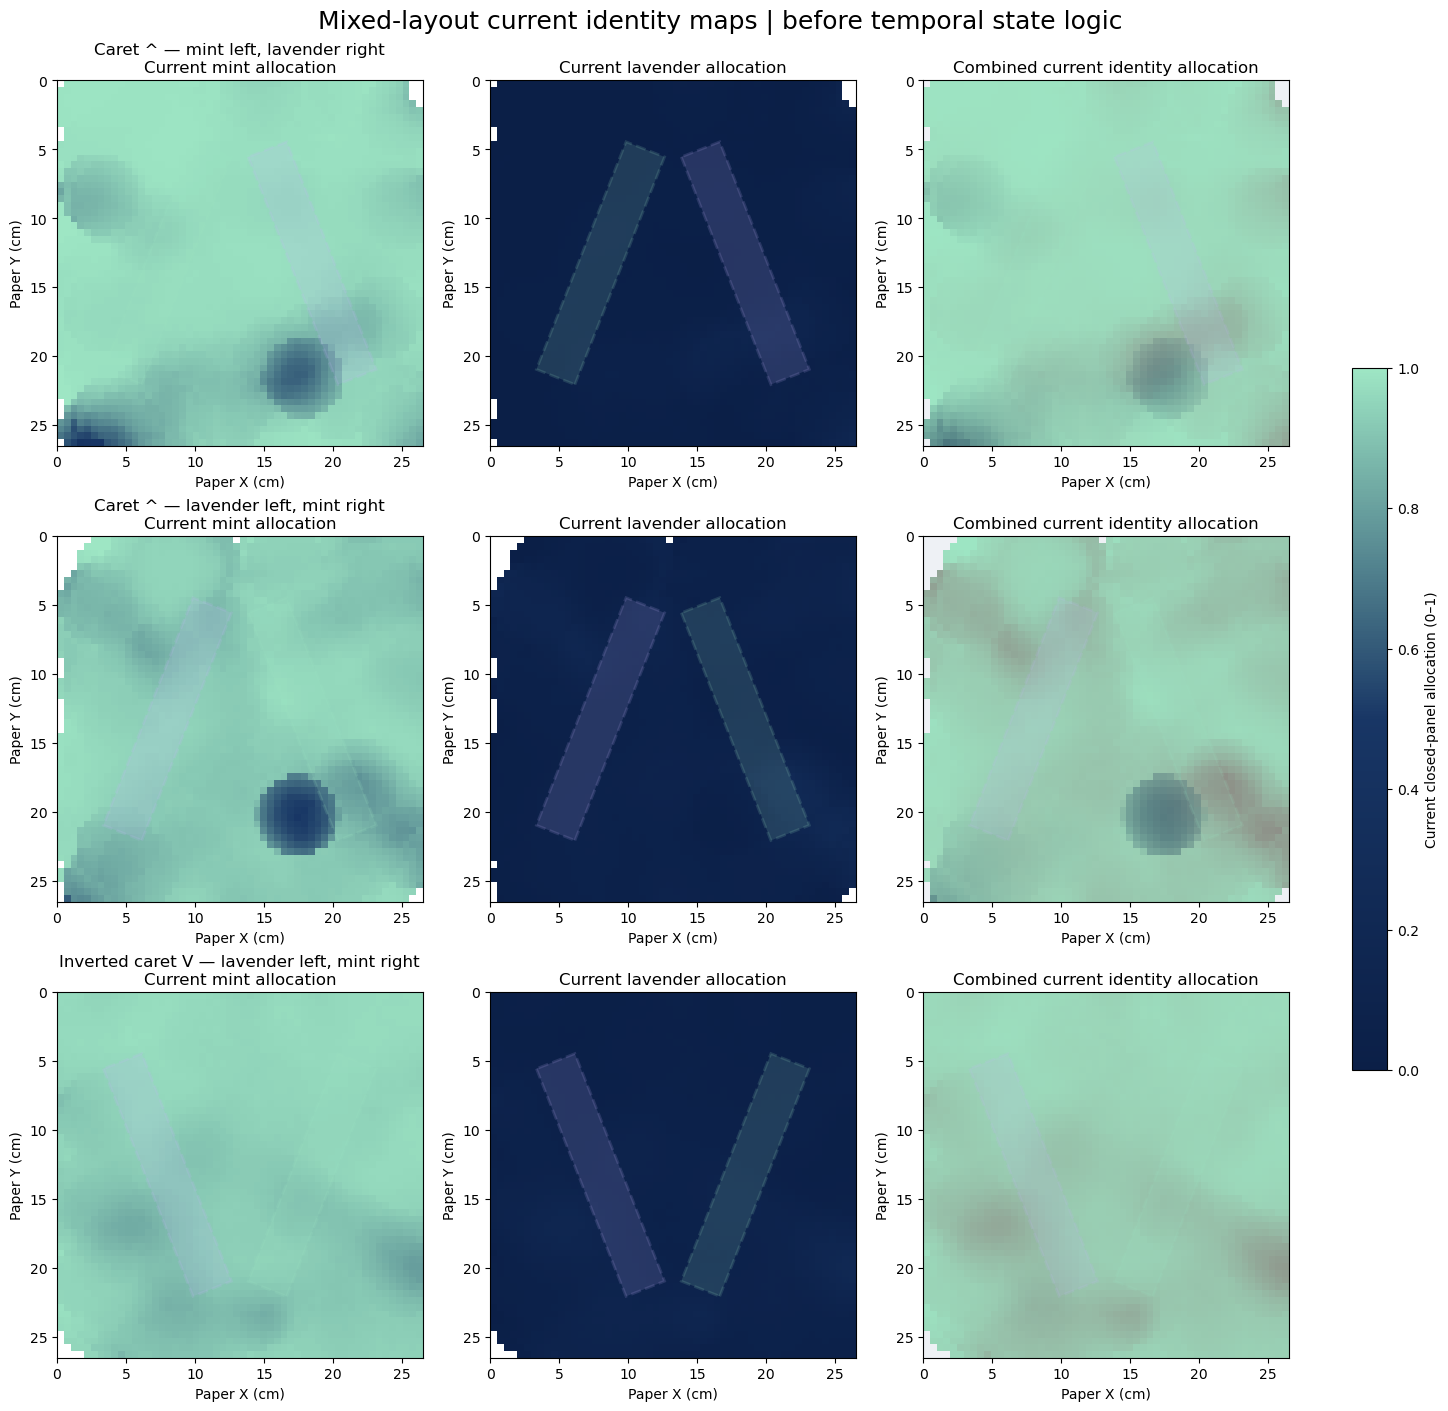

These are the frozen model's **current-reading** allocations before
active/fading temporal state logic. They are useful for seeing where the
closed-panel model finds mint-like versus lavender-like chemistry, but they
remain mutually constrained identity evidence—not calibrated mixture
percentages.

In [9]:
mixed_runs = [
    RUNS["caret_mint_left"],
    RUNS["caret_lavender_left"],
    RUNS["inverted_caret_lavender_left"],
]
fig, axes = plt.subplots(
    3, 3, figsize=(14.5, 14), constrained_layout=True
)
for row, run in enumerate(mixed_runs):
    im = draw_heatmap(
        axes[row, 0],
        run,
        "mint_score",
        MINT_CMAP,
        f"{run['spec']['title']}\nCurrent mint allocation",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 1],
        run,
        "lavender_score",
        LAVENDER_CMAP,
        "Current lavender allocation",
        show_track=False,
    )
    axes[row, 2].imshow(
        combined_rgb(
            run,
            mint_column="mint_score",
            lavender_column="lavender_score",
        ),
        origin="upper",
        extent=[0, PAPER_SIZE_CM, PAPER_SIZE_CM, 0],
        interpolation="nearest",
    )
    add_source_overlays(axes[row, 2], run["spec"], alpha=0.12)
    format_paper_axis(
        axes[row, 2],
        "Combined current identity allocation",
    )

fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.55,
    label="Current closed-panel allocation (0–1)",
)
fig.suptitle(
    "Mixed-layout current identity maps | before temporal state logic",
    fontsize=18,
)
fig.savefig(
    REPORT_DIR / "09_long_random_sequence_current_identity_maps.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(
    Markdown(
        '''These are the frozen model's **current-reading** allocations before
active/fading temporal state logic. They are useful for seeing where the
closed-panel model finds mint-like versus lavender-like chemistry, but they
remain mutually constrained identity evidence—not calibrated mixture
percentages.'''
    )
)


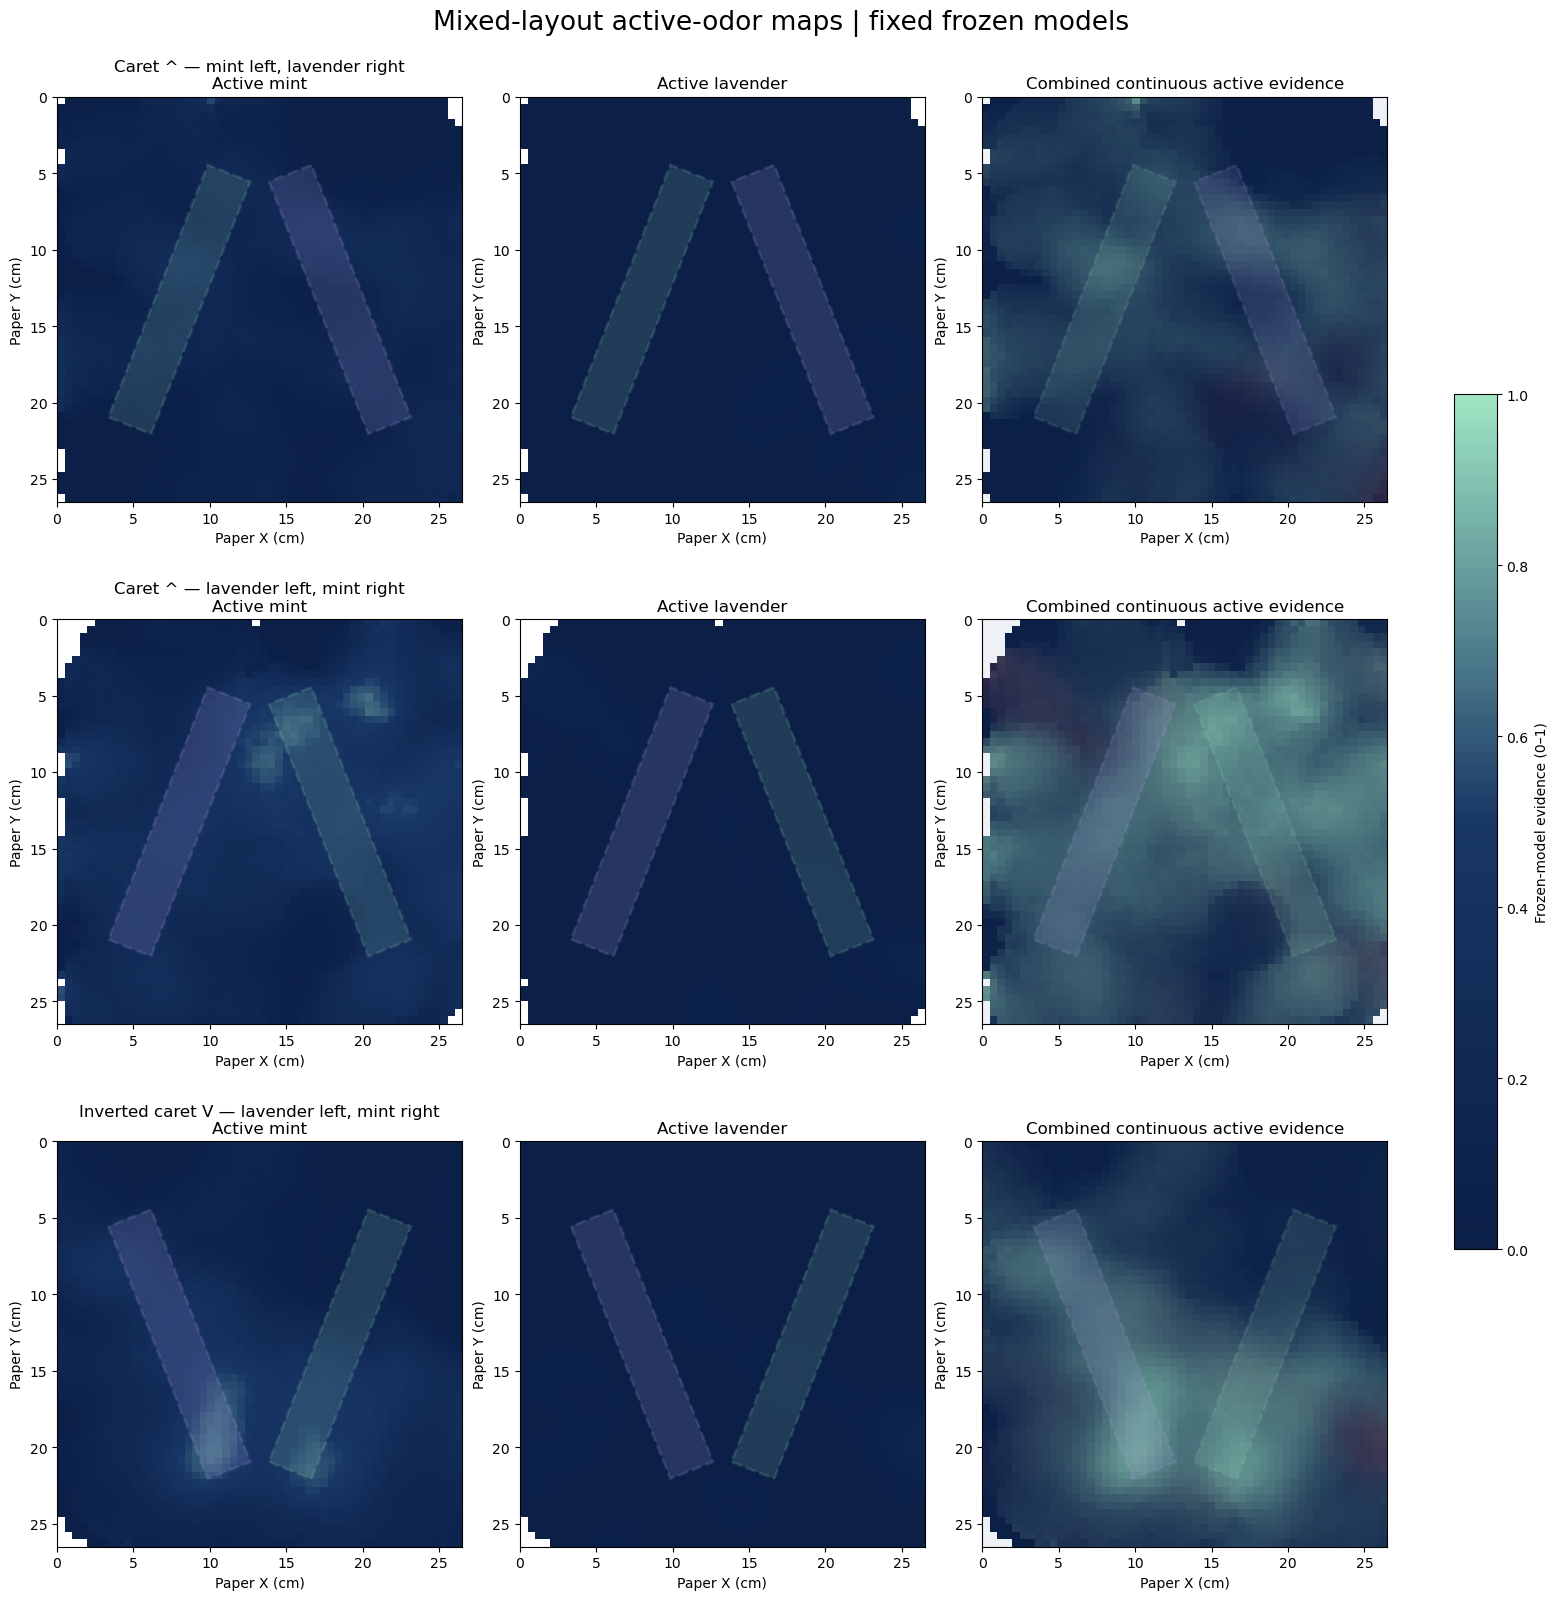

**Combined-map rule.** Green is the evidence unique to the active
mint channel, purple is unique to active lavender, and red is
`min(active mint, active lavender)`: both models are active there, so the
location is ambiguous or overlapping. Red is not proof of a chemical mixture.
The dashed polygons are protocol-approximate physical strips and never alter
the model scores or smoothing.

In [10]:
mixed_runs = [
    RUNS["caret_mint_left"],
    RUNS["caret_lavender_left"],
    RUNS["inverted_caret_lavender_left"],
]
fig, axes = plt.subplots(
    3, 3, figsize=(15.5, 16), constrained_layout=True
)
for row, run in enumerate(mixed_runs):
    im = draw_heatmap(
        axes[row, 0],
        run,
        "active_mint",
        MINT_CMAP,
        f"{run['spec']['title']}\nActive mint",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 1],
        run,
        "active_lavender",
        LAVENDER_CMAP,
        "Active lavender",
        show_track=False,
    )
    axes[row, 2].imshow(
        combined_rgb(run),
        origin="upper",
        extent=[0, PAPER_SIZE_CM, PAPER_SIZE_CM, 0],
        interpolation="nearest",
    )
    add_source_overlays(axes[row, 2], run["spec"], alpha=0.12)
    format_paper_axis(
        axes[row, 2],
        "Combined continuous active evidence",
    )

fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.55,
    label="Frozen-model evidence (0–1)",
)
fig.suptitle(
    "Mixed-layout active-odor maps | fixed frozen models",
    fontsize=19,
)
fig.savefig(
    REPORT_DIR / "09_long_random_sequence_shape_summary.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(
    Markdown(
        '''**Combined-map rule.** Green is the evidence unique to the active
mint channel, purple is unique to active lavender, and red is
`min(active mint, active lavender)`: both models are active there, so the
location is ambiguous or overlapping. Red is not proof of a chemical mixture.
The dashed polygons are protocol-approximate physical strips and never alter
the model scores or smoothing.'''
    )
)


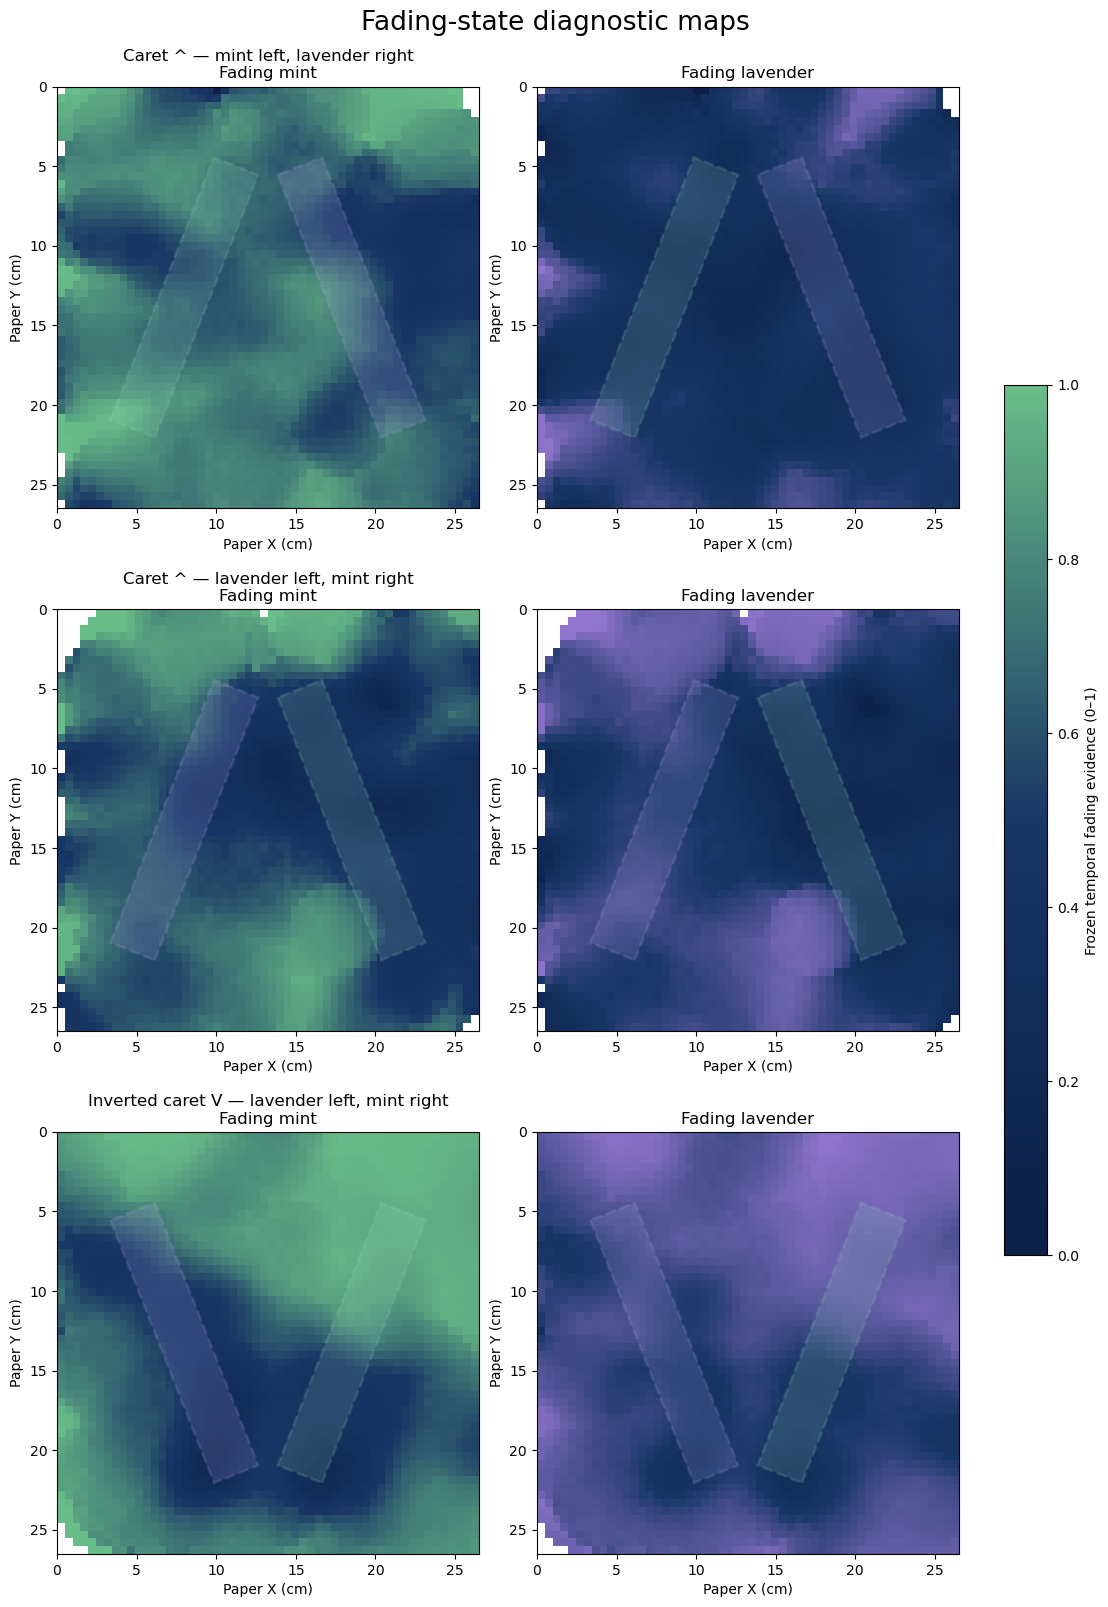

**Fading is history, not a second source.** A bright fading region
means the temporal trajectory resembles post-exposure recovery. In random
motion, a fading plume may appear anywhere visited soon after a source.
Therefore it is diagnostic context rather than shape reconstruction. A future
direction-aware path analysis can test whether it systematically follows
source encounters.

In [11]:
fig, axes = plt.subplots(
    3, 2, figsize=(11, 16), constrained_layout=True
)
for row, run in enumerate(mixed_runs):
    im = draw_heatmap(
        axes[row, 0],
        run,
        "fading_mint",
        MINT_FADE_CMAP,
        f"{run['spec']['title']}\nFading mint",
        show_track=False,
    )
    draw_heatmap(
        axes[row, 1],
        run,
        "fading_lavender",
        LAVENDER_FADE_CMAP,
        "Fading lavender",
        show_track=False,
    )
fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.58,
    label="Frozen temporal fading evidence (0–1)",
)
fig.suptitle(
    "Fading-state diagnostic maps",
    fontsize=19,
)
fig.savefig(
    REPORT_DIR / "09_long_random_sequence_fading_maps.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(
    Markdown(
        '''**Fading is history, not a second source.** A bright fading region
means the temporal trajectory resembles post-exposure recovery. In random
motion, a fading plume may appear anywhere visited soon after a source.
Therefore it is diagnostic context rather than shape reconstruction. A future
direction-aware path analysis can test whether it systematically follows
source encounters.'''
    )
)


In [12]:
def safe_auc(target, score):
    target = np.asarray(target, dtype=bool)
    score = np.asarray(score, dtype=float)
    return (
        float(roc_auc_score(target, score))
        if target.any() and (~target).any()
        else np.nan
    )


def safe_ap(target, score):
    target = np.asarray(target, dtype=bool)
    score = np.asarray(score, dtype=float)
    return (
        float(average_precision_score(target, score))
        if target.any() and (~target).any()
        else np.nan
    )


def geometry_mask_grid(spec, odor):
    return source_mask(
        GRID_POINTS[:, 0],
        GRID_POINTS[:, 1],
        spec["sources"][odor],
    ).reshape(GRID_XX.shape)


def grid_shape_metrics(run, score_column, truth_grid):
    score_grid = run["grids"][score_column]
    support = np.isfinite(score_grid)
    supported_values = score_grid[support]
    supported_truth = truth_grid[support]
    thresholded = supported_values >= 0.5
    union = thresholded | supported_truth
    iou = (
        float(np.sum(thresholded & supported_truth) / np.sum(union))
        if union.any()
        else np.nan
    )
    top_threshold = (
        float(np.quantile(supported_values, 0.80))
        if len(supported_values)
        else np.nan
    )
    top = supported_values >= top_threshold
    top_precision = (
        float(np.mean(supported_truth[top])) if top.any() else np.nan
    )
    return {
        "IoU": iou,
        "top precision": top_precision,
        "source coverage": (
            float(np.mean(support[truth_grid]))
            if truth_grid.any()
            else np.nan
        ),
    }


def odor_metrics(run, odor):
    spec = run["spec"]
    if not spec["sources"][odor]:
        return None
    strict = run["aligned"].loc[
        run["aligned"]["strict_height"]
    ].copy()
    source_column = f"{odor}_source"
    other_odor = "lavender" if odor == "mint" else "mint"
    target = strict[source_column].to_numpy(bool)
    outside = ~target

    truth_grid = geometry_mask_grid(spec, odor)
    current_column = f"{odor}_score"
    active_column = f"active_{odor}"
    wrong_current_column = f"{other_odor}_score"
    wrong_active_column = f"active_{other_odor}"
    current_score = strict[current_column].to_numpy(float)
    active_score = strict[active_column].to_numpy(float)
    current_grid = grid_shape_metrics(
        run, current_column, truth_grid
    )
    active_grid = grid_shape_metrics(
        run, active_column, truth_grid
    )
    return {
        "run": spec["title"],
        "odor": odor,
        "strict rows": len(strict),
        "rows inside approximate source": int(target.sum()),
        "approximate source sampling fraction": float(target.mean()),
        "current source-ranking AUC": safe_auc(
            target, current_score
        ),
        "active source-ranking AUC": safe_auc(
            target, active_score
        ),
        "current average precision": safe_ap(
            target, current_score
        ),
        "active average precision": safe_ap(
            target, active_score
        ),
        "median current inside": (
            float(np.median(current_score[target]))
            if target.any()
            else np.nan
        ),
        "median active inside": (
            float(np.median(active_score[target]))
            if target.any()
            else np.nan
        ),
        "median current outside": (
            float(np.median(current_score[outside]))
            if outside.any()
            else np.nan
        ),
        "median active outside": (
            float(np.median(active_score[outside]))
            if outside.any()
            else np.nan
        ),
        "median wrong-current inside": (
            float(np.median(strict.loc[target, wrong_current_column]))
            if target.any()
            else np.nan
        ),
        "median wrong-odor active inside": (
            float(np.median(strict.loc[target, wrong_active_column]))
            if target.any()
            else np.nan
        ),
        "outside rows active >= 0.5": (
            float(np.mean(active_score[outside] >= 0.5))
            if outside.any()
            else np.nan
        ),
        "supported source-grid coverage": active_grid[
            "source coverage"
        ],
        "current map IoU at 0.5": current_grid["IoU"],
        "active map IoU at 0.5": active_grid["IoU"],
        "current top-20% map precision": current_grid[
            "top precision"
        ],
        "active top-20% map precision": active_grid[
            "top precision"
        ],
    }


metric_rows = []
for run in RUNS.values():
    for odor in ("mint", "lavender"):
        row = odor_metrics(run, odor)
        if row is not None:
            metric_rows.append(row)

shape_metrics = pd.DataFrame(metric_rows)
display(
    shape_metrics.style.format(
        {
            "approximate source sampling fraction": "{:.1%}",
            "current source-ranking AUC": "{:.3f}",
            "active source-ranking AUC": "{:.3f}",
            "current average precision": "{:.3f}",
            "active average precision": "{:.3f}",
            "median current inside": "{:.3f}",
            "median active inside": "{:.3f}",
            "median current outside": "{:.3f}",
            "median active outside": "{:.3f}",
            "median wrong-current inside": "{:.3f}",
            "median wrong-odor active inside": "{:.3f}",
            "outside rows active >= 0.5": "{:.1%}",
            "supported source-grid coverage": "{:.1%}",
            "current map IoU at 0.5": "{:.3f}",
            "active map IoU at 0.5": "{:.3f}",
            "current top-20% map precision": "{:.1%}",
            "active top-20% map precision": "{:.1%}",
        }
    )
)

overall_rows = []
for run in RUNS.values():
    strict = run["aligned"].loc[run["aligned"]["strict_height"]]
    any_source = (
        strict["mint_source"] | strict["lavender_source"]
    ).to_numpy(bool)
    if any_source.any() and (~any_source).any():
        overall_rows.append(
            {
                "run": run["spec"]["title"],
                "any-odor source-ranking AUC": safe_auc(
                    any_source, strict["odor_score"]
                ),
                "RMS-response source-ranking AUC": safe_auc(
                    any_source, strict["rms_pct"]
                ),
                "median odor evidence inside": float(
                    np.median(strict.loc[any_source, "odor_score"])
                ),
                "median odor evidence outside": float(
                    np.median(strict.loc[~any_source, "odor_score"])
                ),
            }
        )
overall_shape_metrics = pd.DataFrame(overall_rows)
display(
    overall_shape_metrics.style.format(
        {
            "any-odor source-ranking AUC": "{:.3f}",
            "RMS-response source-ranking AUC": "{:.3f}",
            "median odor evidence inside": "{:.3f}",
            "median odor evidence outside": "{:.3f}",
        }
    )
)

display(
    Markdown(
        '''**ELI5 for the shape numbers.**

- **Source-ranking AUC** asks whether a randomly selected reading near the
  approximate strip usually gets a higher active score than a reading away
  from it. `0.5` is chance ordering; `1.0` is perfect ordering.
- **Current** is the identity allocation from this reading; **active** adds
  the causal temporal-state requirement.
- **Average precision** rewards concentrating high scores on the relatively
  small strip area.
- **IoU at 0.5** is the literal overlap between the thresholded heatmap and the
  approximate source mask. It is intentionally strict and sensitive to plume
  spread.
- **Top-20% precision** asks what fraction of the brightest fifth of supported
  map cells falls on the intended strip.

These metrics use the declared approximate polygons, so they are exploratory
until measured strip vertices replace the assumptions.'''
    )
)


,run,odor,strict rows,rows inside approximate source,approximate source sampling fraction,current source-ranking AUC,active source-ranking AUC,current average precision,active average precision,median current inside,median active inside,median current outside,median active outside,median wrong-current inside,median wrong-odor active inside,outside rows active >= 0.5,supported source-grid coverage,current map IoU at 0.5,active map IoU at 0.5,current top-20% map precision,active top-20% map precision
0,Mint only — horizontal,mint,564,58,10.3%,0.733,0.639,0.232,0.137,0.998,0.123,0.984,0.016,0.001,0.000,16.0%,100.0%,0.083,0.000,17.6%,14.1%
1,Lavender only — horizontal,lavender,654,76,11.6%,0.482,0.494,0.116,0.120,0.000,0.000,0.000,0.000,0.000,0.000,0.0%,100.0%,0.000,0.000,2.1%,12.3%
2,"Caret ^ — mint left, lavender right",mint,581,54,9.3%,0.514,0.524,0.098,0.101,0.988,0.004,0.986,0.003,0.012,0.000,12.5%,100.0%,0.082,0.000,6.5%,12.6%
3,"Caret ^ — mint left, lavender right",lavender,581,59,10.2%,0.615,0.524,0.139,0.109,0.016,0.000,0.011,0.000,0.984,0.004,0.8%,100.0%,0.000,0.000,13.3%,11.7%
4,"Caret ^ — lavender left, mint right",mint,556,35,6.3%,0.511,0.651,0.064,0.092,0.955,0.411,0.950,0.045,0.045,0.000,27.8%,100.0%,0.083,0.095,16.3%,19.1%
5,"Caret ^ — lavender left, mint right",lavender,556,72,12.9%,0.533,0.523,0.137,0.136,0.041,0.000,0.043,0.000,0.954,0.219,0.2%,100.0%,0.000,0.000,10.8%,13.4%
6,"Inverted caret V — lavender left, mint right",mint,915,94,10.3%,0.508,0.553,0.100,0.115,0.953,0.054,0.954,0.039,0.047,0.000,23.9%,100.0%,0.082,0.074,3.8%,17.5%
7,"Inverted caret V — lavender left, mint right",lavender,915,106,11.6%,0.541,0.489,0.124,0.106,0.053,0.000,0.046,0.000,0.947,0.482,0.5%,100.0%,0.000,0.000,7.9%,0.3%


,run,any-odor source-ranking AUC,RMS-response source-ranking AUC,median odor evidence inside,median odor evidence outside
0,Mint only — horizontal,0.839,0.858,1.000,0.996
1,Lavender only — horizontal,0.533,0.622,0.000,0.000
2,"Caret ^ — mint left, lavender right",0.617,0.624,1.000,1.000
3,"Caret ^ — lavender left, mint right",0.646,0.683,1.000,1.000
4,"Inverted caret V — lavender left, mint right",0.658,0.700,1.000,1.000


**ELI5 for the shape numbers.**

- **Source-ranking AUC** asks whether a randomly selected reading near the
  approximate strip usually gets a higher active score than a reading away
  from it. `0.5` is chance ordering; `1.0` is perfect ordering.
- **Current** is the identity allocation from this reading; **active** adds
  the causal temporal-state requirement.
- **Average precision** rewards concentrating high scores on the relatively
  small strip area.
- **IoU at 0.5** is the literal overlap between the thresholded heatmap and the
  approximate source mask. It is intentionally strict and sensitive to plume
  spread.
- **Top-20% precision** asks what fraction of the brightest fifth of supported
  map cells falls on the intended strip.

These metrics use the declared approximate polygons, so they are exploratory
until measured strip vertices replace the assumptions.

In [13]:
lag_rows = []
for run in RUNS.values():
    spec = run["spec"]
    for lag_s in LAG_SENSITIVITY_S:
        local = align_scores_to_paper(run, lag_s)
        strict = local.loc[local["strict_height"]]
        for odor in ("mint", "lavender"):
            if not spec["sources"][odor]:
                continue
            lag_rows.append(
                {
                    "run": spec["title"],
                    "odor": odor,
                    "lag (s)": lag_s,
                    "strict rows": len(strict),
                    "source-ranking AUC": safe_auc(
                        strict[f"{odor}_source"],
                        strict[f"active_{odor}"],
                    ),
                }
            )

lag_sensitivity = pd.DataFrame(lag_rows)
display(
    lag_sensitivity.pivot_table(
        index=["run", "odor"],
        columns="lag (s)",
        values="source-ranking AUC",
    ).style.format("{:.3f}")
)

lag_spread = (
    lag_sensitivity.groupby(["run", "odor"])["source-ranking AUC"]
    .agg(["min", "max"])
    .assign(spread=lambda local: local["max"] - local["min"])
    .reset_index()
)
display(lag_spread.style.format({"min": "{:.3f}", "max": "{:.3f}", "spread": "{:.3f}"}))

display(
    Markdown(
        '''**Lag sensitivity.** The 2.0 s correction stays fixed as the primary
analysis. The neighboring 1.5 and 2.25 s values are shown only to check whether
the conclusion disappears after a small physically plausible timing change.
No lag is selected from the best-looking result.'''
    )
)


,run,odor,min,max,spread
0,"Caret ^ — lavender left, mint right",lavender,0.503,0.568,0.064
1,"Caret ^ — lavender left, mint right",mint,0.634,0.668,0.034
2,"Caret ^ — mint left, lavender right",lavender,0.505,0.592,0.087
3,"Caret ^ — mint left, lavender right",mint,0.509,0.544,0.036
4,"Inverted caret V — lavender left, mint right",lavender,0.465,0.605,0.140
5,"Inverted caret V — lavender left, mint right",mint,0.553,0.578,0.026
6,Lavender only — horizontal,lavender,0.484,0.518,0.034
7,Mint only — horizontal,mint,0.610,0.740,0.130


**Lag sensitivity.** The 2.0 s correction stays fixed as the primary
analysis. The neighboring 1.5 and 2.25 s values are shown only to check whether
the conclusion disappears after a small physically plausible timing change.
No lag is selected from the best-looking result.

In [14]:
summary = shape_metrics[
    [
        "run",
        "odor",
        "current source-ranking AUC",
        "active source-ranking AUC",
        "median active inside",
        "median active outside",
        "median wrong-odor active inside",
        "active map IoU at 0.5",
        "active top-20% map precision",
    ]
].copy()

strongest = summary.loc[
    summary["active source-ranking AUC"].idxmax()
]
weakest = summary.loc[
    summary["active source-ranking AUC"].idxmin()
]
median_current_auc = float(
    summary["current source-ranking AUC"].median()
)
median_active_auc = float(
    summary["active source-ranking AUC"].median()
)
median_overall_auc = float(
    overall_shape_metrics["any-odor source-ranking AUC"].median()
)
median_iou = float(summary["active map IoU at 0.5"].median())
max_lag_spread = float(lag_spread["spread"].max())

display(
    Markdown(
        f'''## What this pilot supports

- The five reviewed recordings contain **{sum(len(run['frame']) for run in RUNS.values()):,}**
  Cyranose rows. Every run retains complete 32-channel data and 100% digital
  Cyranose–pose matches inside the 250 ms rule.
- Across the declared odor/source comparisons, median point-level
  source-ranking AUC is **{median_current_auc:.3f}** for current identity
  allocation and **{median_active_auc:.3f}** after temporal active-state logic.
  The median identity-independent any-odor AUC is
  **{median_overall_auc:.3f}**.
- The strongest active-state comparison is
  **{strongest['run']} / {strongest['odor']}** at
  **{strongest['active source-ranking AUC']:.3f}**; the weakest is
  **{weakest['run']} / {weakest['odor']}** at
  **{weakest['active source-ranking AUC']:.3f}**.
- Median thresholded map IoU is **{median_iou:.3f}**. AUC can be encouraging
  while IoU remains modest because odor transport and sensor recovery produce
  broad fields rather than paper-sharp boundaries.
- The largest AUC change across the fixed 1.5, 2.0, and 2.25 s timing check is
  **{max_lag_spread:.3f}**. Large spreads identify conclusions that remain
  timing-sensitive.

### Interpretation boundary

This notebook tests whether the frozen evidence fields retain **useful spatial
structure**, not whether they perfectly trace soaked paper. The combined maps
are continuous evidence views: green, purple, and red do not represent
calibrated mint/lavender percentages. Exact shape-accuracy claims should wait
until source endpoints and widths are measured in paper coordinates or
registered from a setup photograph. Until then, treat the AUC, IoU, and
top-region results as sensitivity analyses around the documented protocol
geometry.
'''
    )
)


## What this pilot supports

- The five reviewed recordings contain **4,145**
  Cyranose rows. Every run retains complete 32-channel data and 100% digital
  Cyranose–pose matches inside the 250 ms rule.
- Across the declared odor/source comparisons, median point-level
  source-ranking AUC is **0.523** for current identity
  allocation and **0.524** after temporal active-state logic.
  The median identity-independent any-odor AUC is
  **0.646**.
- The strongest active-state comparison is
  **Caret ^ — lavender left, mint right / mint** at
  **0.651**; the weakest is
  **Inverted caret V — lavender left, mint right / lavender** at
  **0.489**.
- Median thresholded map IoU is **0.000**. AUC can be encouraging
  while IoU remains modest because odor transport and sensor recovery produce
  broad fields rather than paper-sharp boundaries.
- The largest AUC change across the fixed 1.5, 2.0, and 2.25 s timing check is
  **0.140**. Large spreads identify conclusions that remain
  timing-sensitive.

### Interpretation boundary

This notebook tests whether the frozen evidence fields retain **useful spatial
structure**, not whether they perfectly trace soaked paper. The combined maps
are continuous evidence views: green, purple, and red do not represent
calibrated mint/lavender percentages. Exact shape-accuracy claims should wait
until source endpoints and widths are measured in paper coordinates or
registered from a setup photograph. Until then, treat the AUC, IoU, and
top-region results as sensitivity analyses around the documented protocol
geometry.
